In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [16]:
#Cargamos el archivo csv con pandas
#Cargamos solamente:
#- Las columnas A hasta L
#- Las filas de datos hasta la fila 32 de Excel
#- La fila 3 de Excel será el encabezado

df_raw= pd.read_csv(
    "leads_reales.csv",
    skiprows=2,        #Omite las filas 1 y 2
    nrows=29,          #Lee únicamente las filas 4 a 32
    usecols=range(12), #Conserva solamente las columnas A a L
    dtype=str
)

In [17]:
header=2

In [18]:
valores_nulos_Leads = df_raw.isnull().sum()
valores_nulos_Leads

Año                     26
Mes                      0
Total                    1
Ilocalizable             1
No Contesta              1
D. Incorrectos           1
Duplicados               1
Efectivos                1
Abiertos                 1
Ventas                   1
Conversion               1
Efectividad de Leads     1
dtype: int64

In [19]:
df_raw.loc[0:28, "Año"] = df_raw.loc[0:28, "Año"].ffill()
df_raw.loc[0:28, ["Año", "Mes"]]

,Año,Mes
0,2024,Enero
1,2024,Febrero
2,2024,Marzo
3,2024,Abril
4,2024,Mayo
5,2024,Junio
6,2024,Julio
7,2024,Agosto
8,2024,Septiembre
9,2024,Octubre


In [20]:
valores_nulos_Leads = df_raw.isnull().sum()
valores_nulos_Leads

Año                     0
Mes                     0
Total                   1
Ilocalizable            1
No Contesta             1
D. Incorrectos          1
Duplicados              1
Efectivos               1
Abiertos                1
Ventas                  1
Conversion              1
Efectividad de Leads    1
dtype: int64

In [21]:
print(df_raw)

     Año         Mes  Total Ilocalizable No Contesta D. Incorrectos  \
0   2024       Enero    NaN          NaN         NaN            NaN   
1   2024     Febrero    543          108          33              0   
2   2024       Marzo    178           37          13              0   
3   2024       Abril    416           79          46              3   
4   2024        Mayo    422           33         100             17   
5   2024       Junio    967          140         173             31   
6   2024       Julio    954          112         251             12   
7   2024      Agosto  1,409          504         324             17   
8   2024  Septiembre  1,315          431         314             14   
9   2024     Octubre  1,973          514         606             18   
10  2024   Noviembre  1,562          153         321             44   
11  2024   Diciembre  1,282          374         193             60   
12  2025      Enero   1,042           17         104             62   
13  20

In [22]:
#Declaramos las columnas que contienen cantidades

columnas_conteo = [
    "Total",
    "Ilocalizable",
    "No Contesta",
    "D. Incorrectos",
    "Duplicados",
    "Efectivos",
    "Abiertos",
    "Ventas"
]

#Quitamos las comas de miles y convertimos a números

for columna in columnas_conteo:
    df_raw[columna] = pd.to_numeric(
        df_raw[columna].str.replace(",", "", regex=False),
        errors="coerce"
    )

#Convertimos el año a número entero

df_raw["Año"] = pd.to_numeric(
    df_raw["Año"],
    errors="coerce"
).astype("Int64")

In [23]:
#Quitamos el símbolo de porcentaje
#y dividimos el resultado entre 100

columnas_porcentaje = [
    "Conversion ",
    "Efectividad de Leads"
]

for columna in columnas_porcentaje:
    df_raw[columna] = (
        pd.to_numeric(
            df_raw[columna].str.replace("%", "", regex=False),
            errors="coerce"
        ) / 100
    )

df_raw.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024,Febrero,543.0,108.0,33.0,0.0,1.0,389.0,1.0,12.0,0.031,0.72
2,2024,Marzo,178.0,37.0,13.0,0.0,0.0,128.0,1.0,7.0,0.055,0.72
3,2024,Abril,416.0,79.0,46.0,3.0,0.0,288.0,1.0,8.0,0.028,0.69
4,2024,Mayo,422.0,33.0,100.0,17.0,0.0,274.0,5.0,13.0,0.047,0.65


In [24]:
#Asignamos un número a cada mes

meses = {
    "Enero": 1,
    "Febrero": 2,
    "Marzo": 3,
    "Abril": 4,
    "Mayo": 5,
    "Junio": 6,
    "Julio": 7,
    "Agosto": 8,
    "Septiembre": 9,
    "Octubre": 10,
    "Noviembre": 11,
    "Diciembre": 12
}

#Reemplazamos los nombres de los meses por números
#dentro de la misma columna Mes

df_raw["Mes"] = (
    df_raw["Mes"]
    .astype(str)
    .str.strip()
    .map(meses)
)

df_raw.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024,2,543.0,108.0,33.0,0.0,1.0,389.0,1.0,12.0,0.031,0.72
2,2024,3,178.0,37.0,13.0,0.0,0.0,128.0,1.0,7.0,0.055,0.72
3,2024,4,416.0,79.0,46.0,3.0,0.0,288.0,1.0,8.0,0.028,0.69
4,2024,5,422.0,33.0,100.0,17.0,0.0,274.0,5.0,13.0,0.047,0.65


In [25]:
#Quitamos espacios de los nombres de las columnas

df_raw.columns = df_raw.columns.str.strip()

#Eliminamos Enero de 2024 porque no contiene datos

df_raw = df_raw.dropna(subset=["Total"]).copy()

#Reiniciamos el índice

df_raw = df_raw.reset_index(drop=True)

df_raw.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024,2,543.0,108.0,33.0,0.0,1.0,389.0,1.0,12.0,0.031,0.72
1,2024,3,178.0,37.0,13.0,0.0,0.0,128.0,1.0,7.0,0.055,0.72
2,2024,4,416.0,79.0,46.0,3.0,0.0,288.0,1.0,8.0,0.028,0.69
3,2024,5,422.0,33.0,100.0,17.0,0.0,274.0,5.0,13.0,0.047,0.65
4,2024,6,967.0,140.0,173.0,31.0,3.0,620.0,17.0,6.0,0.010,0.64


In [26]:
#Columnas que deben contener números enteros

columnas_enteras = [
    "Año",
    "Mes",
    "Total",
    "Ilocalizable",
    "No Contesta",
    "D. Incorrectos",
    "Duplicados",
    "Efectivos",
    "Abiertos",
    "Ventas"
]

for columna in columnas_enteras:
    df_raw[columna] = df_raw[columna].astype(int)

df_raw.dtypes

Año                       int64
Mes                       int64
Total                     int64
Ilocalizable              int64
No Contesta               int64
D. Incorrectos            int64
Duplicados                int64
Efectivos                 int64
Abiertos                  int64
Ventas                    int64
Conversion              float64
Efectividad de Leads    float64
dtype: object

In [27]:
print("Tamaño final:", df_raw.shape)
print("Valores nulos:", df_raw.isnull().sum().sum())
print("Filas duplicadas:", df_raw.duplicated().sum())
print("\nTipos de datos:")
print(df_raw.dtypes)

Tamaño final: (28, 12)
Valores nulos: 0
Filas duplicadas: 0

Tipos de datos:
Año                       int64
Mes                       int64
Total                     int64
Ilocalizable              int64
No Contesta               int64
D. Incorrectos            int64
Duplicados                int64
Efectivos                 int64
Abiertos                  int64
Ventas                    int64
Conversion              float64
Efectividad de Leads    float64
dtype: object


In [30]:
%pip install --no-cache-dir openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


In [31]:
#Creamos un archivo Excel con la base limpia

df_raw.to_excel(
    "Leads_Reales_Limpia.xlsx",
    index=False
)

In [32]:
#Cargamos la base limpia de Leads Reales

df = pd.read_excel("Leads_Reales_Limpia.xlsx")

#Quitamos posibles espacios en los encabezados

df.columns = df.columns.str.strip()

df.head(5)

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024,2,543,108,33,0,1,389,1,12,0.031,0.72
1,2024,3,178,37,13,0,0,128,1,7,0.055,0.72
2,2024,4,416,79,46,3,0,288,1,8,0.028,0.69
3,2024,5,422,33,100,17,0,274,5,13,0.047,0.65
4,2024,6,967,140,173,31,3,620,17,6,0.010,0.64


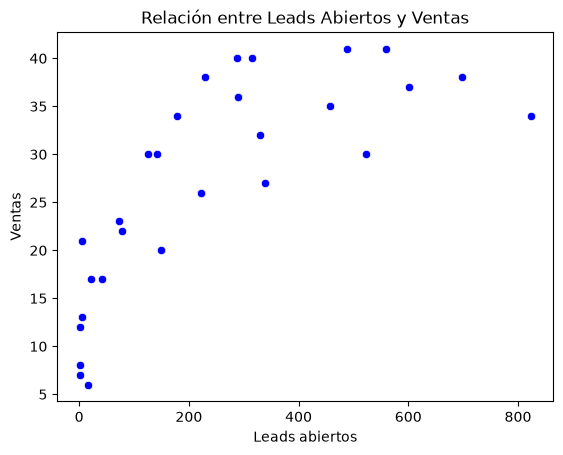

In [33]:
#Imprimimos el scatter plot entre la variable dependiente (Ventas)
#e independiente (Abiertos) para observar su comportamiento

sns.scatterplot(
    x="Abiertos",
    y="Ventas",
    color="blue",
    data=df
)

plt.title("Relación entre Leads Abiertos y Ventas")
plt.xlabel("Leads abiertos")
plt.ylabel("Ventas")
plt.show()

In [34]:
#Calculamos la correlación entre Abiertos y Ventas

correlacion = df["Abiertos"].corr(df["Ventas"])

print("Correlación entre Abiertos y Ventas:", correlacion)

Correlación entre Abiertos y Ventas: 0.7525510570298674


In [35]:
#Declaramos la variable independiente y dependiente
#para la regresión lineal

Vars_Indep = df[["Abiertos"]]

Var_Dep = df["Ventas"]

In [36]:
!pip install scikit-learn

In [37]:
#Instalamos la librería scikit-learn
#Importamos la función de regresión lineal


from sklearn.linear_model import LinearRegression

#Definimos model como la función de regresión lineal

model = LinearRegression()

In [38]:
#Ajustamos el modelo con las variables antes declaradas

model.fit(
    X=Vars_Indep,
    y=Var_Dep
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.04]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Abiertos']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,18.13
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [39]:
#Verificamos los coeficientes obtenidos
#para el modelo ajustado

model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Abiertos'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.03533478]),
 'rank_': np.int64(1),
 'singular_': array([1226.60290175]),
 'intercept_': np.float64(18.126805081456116)}

In [40]:
#Mostramos el intercepto y la pendiente del modelo

print("Intercepto:", model.intercept_)
print("Pendiente:", model.coef_[0])

Intercepto: 18.126805081456116
Pendiente: 0.03533477905458072


In [41]:
#Mostramos la ecuación de regresión lineal

print(
    f"Ventas = {model.intercept_:.4f} "
    f"+ {model.coef_[0]:.4f}(Abiertos)"
)

Ventas = 18.1268 + 0.0353(Abiertos)


In [42]:
#Evaluamos la eficiencia del modelo mediante
#el coeficiente de determinación R cuadrada

coef_Deter = model.score(
    Vars_Indep,
    Var_Dep
)

print("Coeficiente de determinación R²:", coef_Deter)

Coeficiente de determinación R²: 0.5663330934367705


In [43]:
#Predecimos las Ventas a partir de los Leads Abiertos

y_pred = model.predict(
    X=df[["Abiertos"]]
)

y_pred

array([18.16213986, 18.16213986, 18.16213986, 18.30347898, 18.72749633,
       18.30347898, 18.90417022, 19.6108658 , 20.67090917, 20.91825263,
       29.78728217, 25.97112603, 23.42702194, 22.54365246, 23.10900893,
       24.45173053, 29.25726048, 28.37389101, 30.0699604 , 26.21846948,
       28.30322145, 35.37017726, 47.20732824, 39.39834207, 36.60689453,
       42.79048086, 37.87894657, 34.31013389])

In [44]:
#Insertamos las predicciones en el DataFrame

df["Predicciones"] = y_pred

df.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads,Predicciones
0,2024,2,543,108,33,0,1,389,1,12,0.031,0.72,18.162140
1,2024,3,178,37,13,0,0,128,1,7,0.055,0.72,18.162140
2,2024,4,416,79,46,3,0,288,1,8,0.028,0.69,18.162140
3,2024,5,422,33,100,17,0,274,5,13,0.047,0.65,18.303479
4,2024,6,967,140,173,31,3,620,17,6,0.010,0.64,18.727496


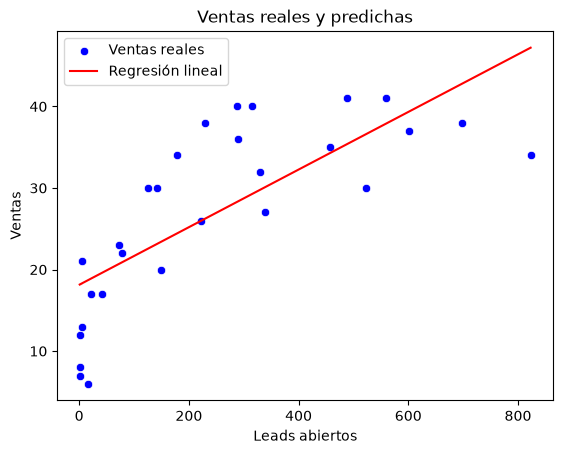

In [45]:
#Visualizamos la comparación entre las Ventas reales
#y las Ventas predichas por el modelo

sns.scatterplot(
    x="Abiertos",
    y="Ventas",
    color="blue",
    data=df,
    label="Ventas reales"
)

sns.lineplot(
    x="Abiertos",
    y="Predicciones",
    color="red",
    data=df.sort_values("Abiertos"),
    label="Regresión lineal"
)

plt.title("Ventas reales y predichas")
plt.xlabel("Leads abiertos")
plt.ylabel("Ventas")
plt.show()

In [46]:
#Calculamos el coeficiente de correlación

coef_Correl = df["Abiertos"].corr(df["Ventas"])

print("Coeficiente de correlación:", coef_Correl)

Coeficiente de correlación: 0.7525510570298674


In [47]:
#Seleccionamos únicamente las columnas numéricas

df_numerico = df.select_dtypes(
    include=["number"]
)

df_numerico.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads,Predicciones
0,2024,2,543,108,33,0,1,389,1,12,0.031,0.72,18.162140
1,2024,3,178,37,13,0,0,128,1,7,0.055,0.72,18.162140
2,2024,4,416,79,46,3,0,288,1,8,0.028,0.69,18.162140
3,2024,5,422,33,100,17,0,274,5,13,0.047,0.65,18.303479
4,2024,6,967,140,173,31,3,620,17,6,0.010,0.64,18.727496


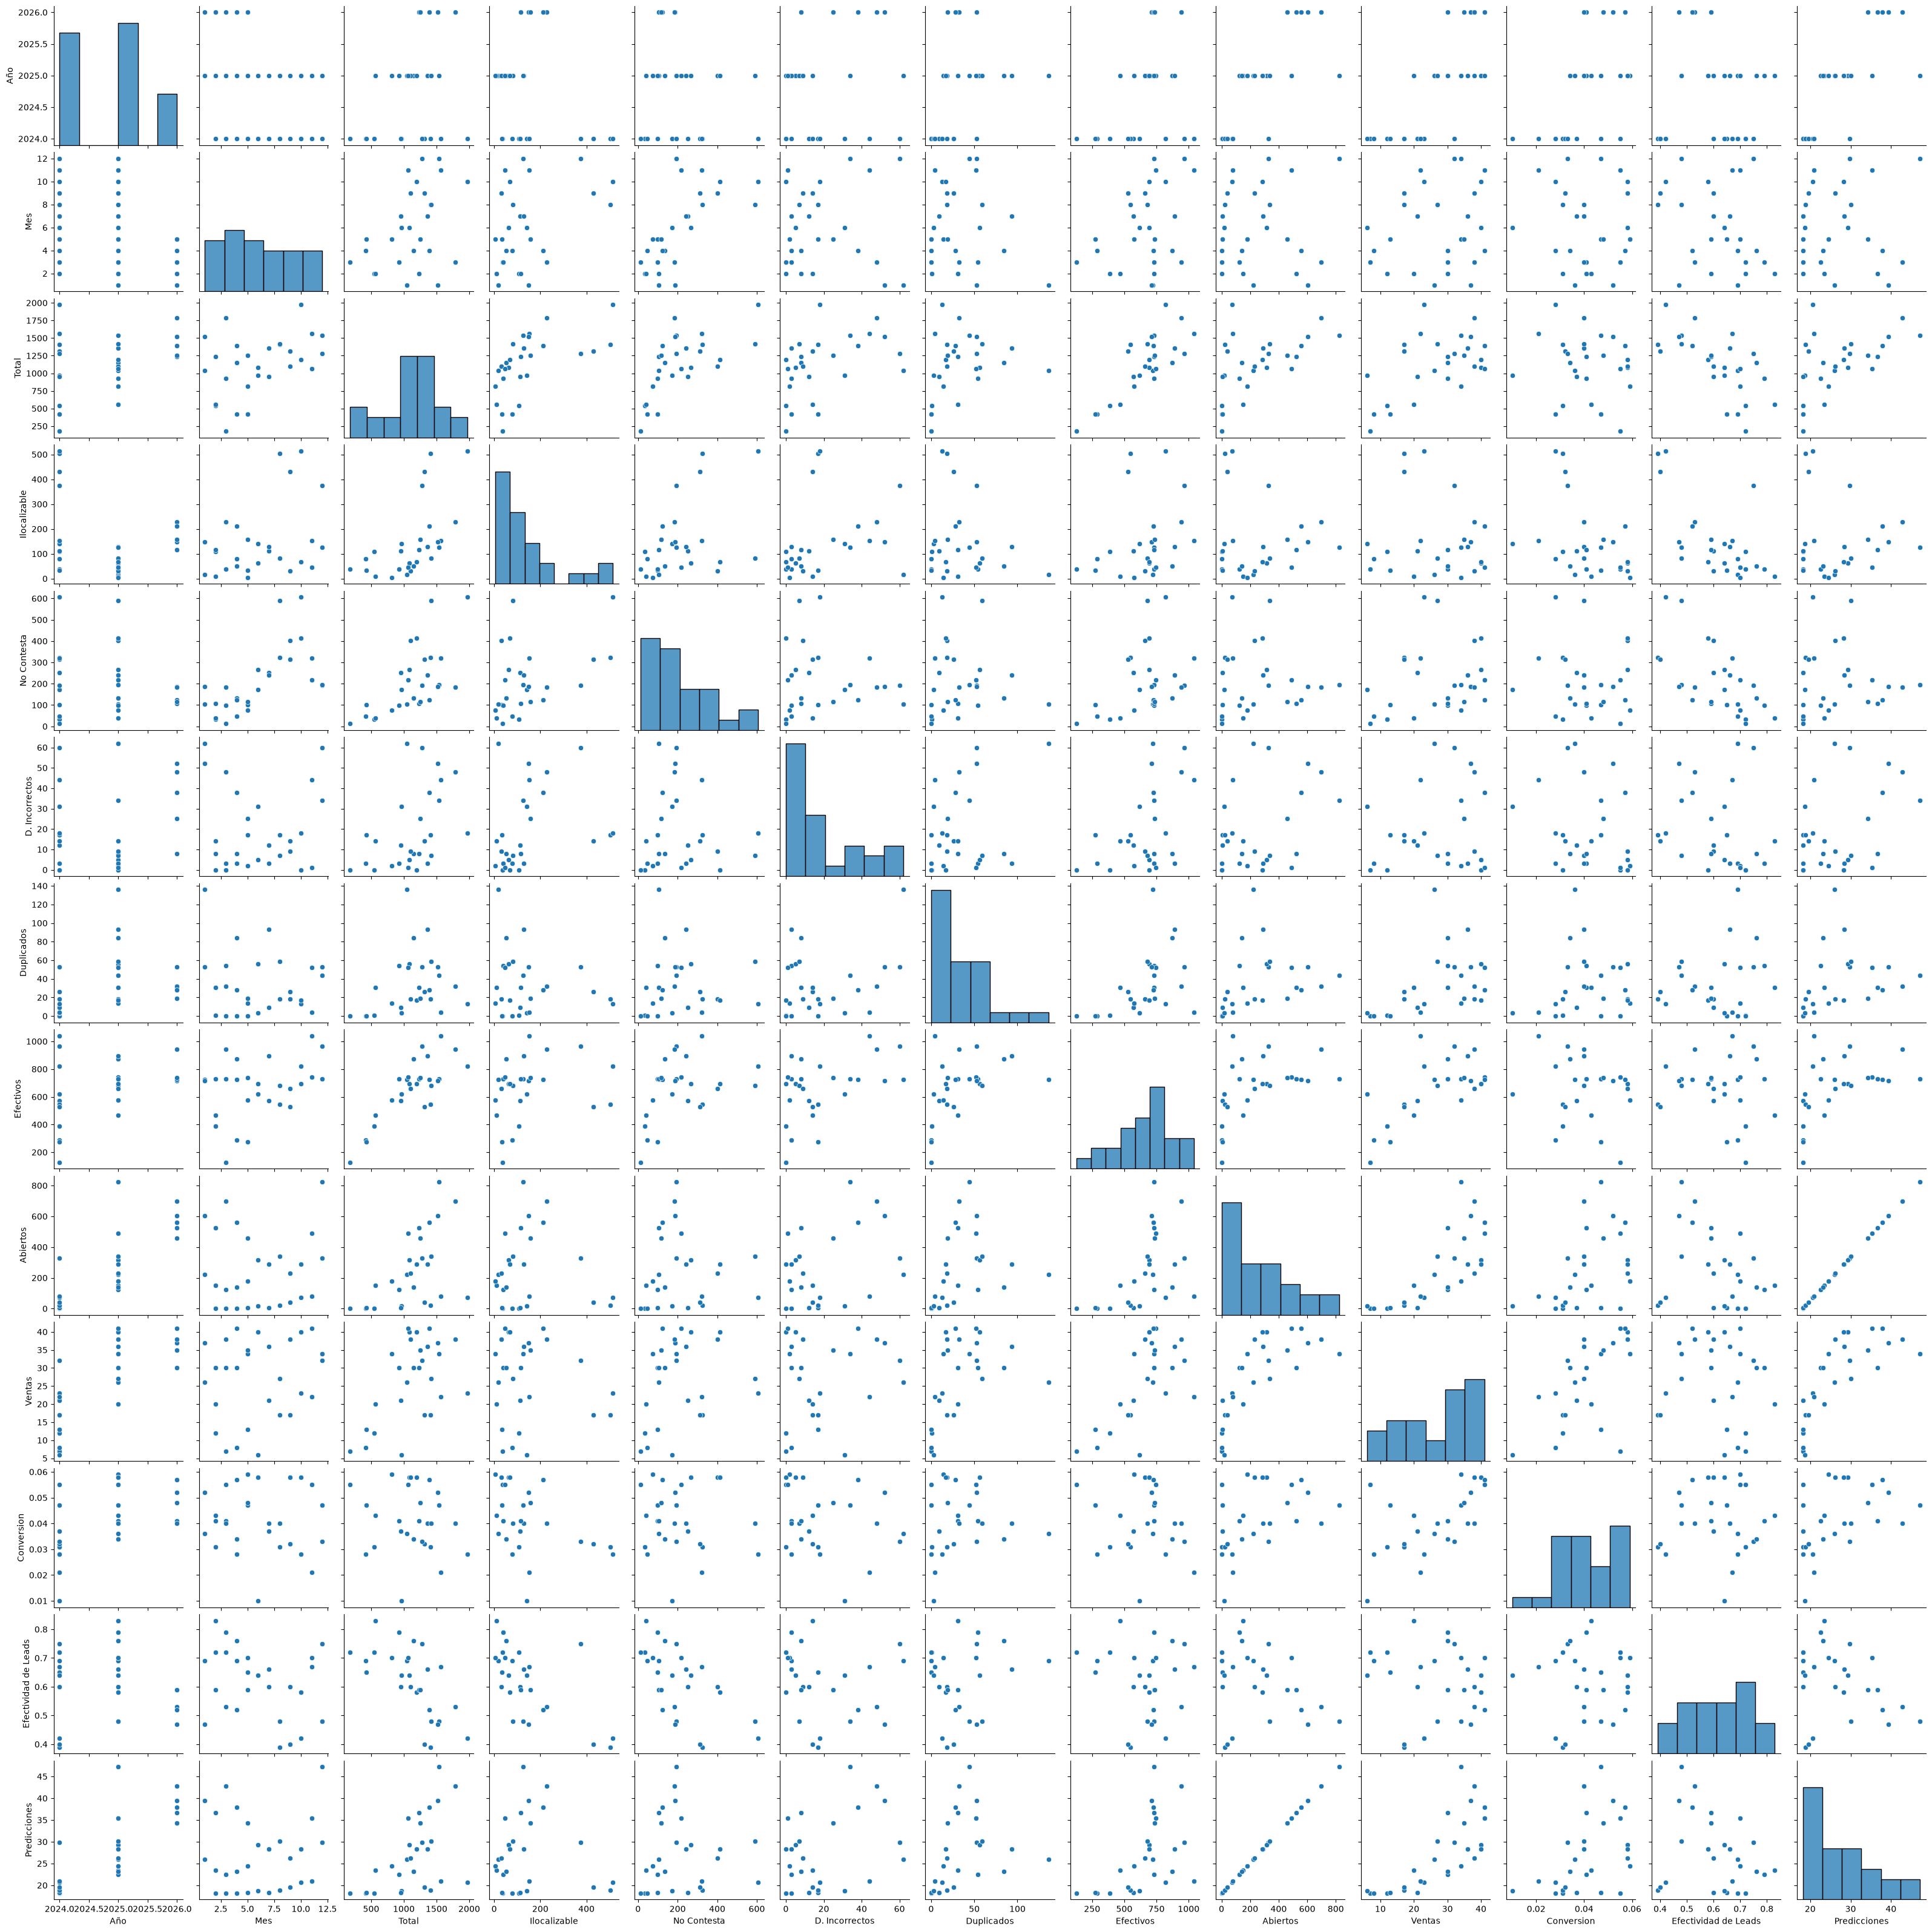

In [48]:
#Graficamos las dispersiones entre las variables

sns.pairplot(df_numerico)

plt.show()

In [49]:
#Encontramos las correlaciones entre todas las variables

Corr_Factors = df_numerico.corr()

Corr_Factors

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads,Predicciones
Año,1.000000,-0.371581,0.344364,-0.266705,-0.131004,0.180612,0.372096,0.387510,0.800323,0.745898,0.536228,-0.105934,0.800323
Mes,-0.371581,1.000000,0.417563,0.393890,0.641403,0.000990,-0.136307,0.355581,0.054022,0.184924,-0.077131,-0.302947,0.054022
Total,0.344364,0.417563,1.000000,0.588110,0.644815,0.453006,0.260949,0.812001,0.528382,0.534564,-0.133595,-0.653776,0.528382
Ilocalizable,-0.266705,0.393890,0.588110,1.000000,0.443577,0.293649,-0.162391,0.245740,-0.047827,-0.106959,-0.413785,-0.645820,-0.047827
No Contesta,-0.131004,0.641403,0.644815,0.443577,1.000000,-0.040028,0.012199,0.383725,0.013522,0.219976,-0.088043,-0.611360,0.013522
D. Incorrectos,0.180612,0.000990,0.453006,0.293649,-0.040028,1.000000,0.287165,0.468292,0.382420,0.143903,-0.247300,-0.177488,0.382420
Duplicados,0.372096,-0.136307,0.260949,-0.162391,0.012199,0.287165,1.000000,0.467451,0.336402,0.451099,0.085728,0.139829,0.336402
Efectivos,0.387510,0.355581,0.812001,0.245740,0.383725,0.468292,0.467451,1.000000,0.495192,0.654887,-0.137212,-0.115353,0.495192
Abiertos,0.800323,0.054022,0.528382,-0.047827,0.013522,0.382420,0.336402,0.495192,1.000000,0.752551,0.445734,-0.281941,1.000000
Ventas,0.745898,0.184924,0.534564,-0.106959,0.219976,0.143903,0.451099,0.654887,0.752551,1.000000,0.626595,-0.115155,0.752551


In [50]:
#Encontramos el valor absoluto de las correlaciones

Corr_Factors1 = abs(Corr_Factors)

Corr_Factors1

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads,Predicciones
Año,1.000000,0.371581,0.344364,0.266705,0.131004,0.180612,0.372096,0.387510,0.800323,0.745898,0.536228,0.105934,0.800323
Mes,0.371581,1.000000,0.417563,0.393890,0.641403,0.000990,0.136307,0.355581,0.054022,0.184924,0.077131,0.302947,0.054022
Total,0.344364,0.417563,1.000000,0.588110,0.644815,0.453006,0.260949,0.812001,0.528382,0.534564,0.133595,0.653776,0.528382
Ilocalizable,0.266705,0.393890,0.588110,1.000000,0.443577,0.293649,0.162391,0.245740,0.047827,0.106959,0.413785,0.645820,0.047827
No Contesta,0.131004,0.641403,0.644815,0.443577,1.000000,0.040028,0.012199,0.383725,0.013522,0.219976,0.088043,0.611360,0.013522
D. Incorrectos,0.180612,0.000990,0.453006,0.293649,0.040028,1.000000,0.287165,0.468292,0.382420,0.143903,0.247300,0.177488,0.382420
Duplicados,0.372096,0.136307,0.260949,0.162391,0.012199,0.287165,1.000000,0.467451,0.336402,0.451099,0.085728,0.139829,0.336402
Efectivos,0.387510,0.355581,0.812001,0.245740,0.383725,0.468292,0.467451,1.000000,0.495192,0.654887,0.137212,0.115353,0.495192
Abiertos,0.800323,0.054022,0.528382,0.047827,0.013522,0.382420,0.336402,0.495192,1.000000,0.752551,0.445734,0.281941,1.000000
Ventas,0.745898,0.184924,0.534564,0.106959,0.219976,0.143903,0.451099,0.654887,0.752551,1.000000,0.626595,0.115155,0.752551


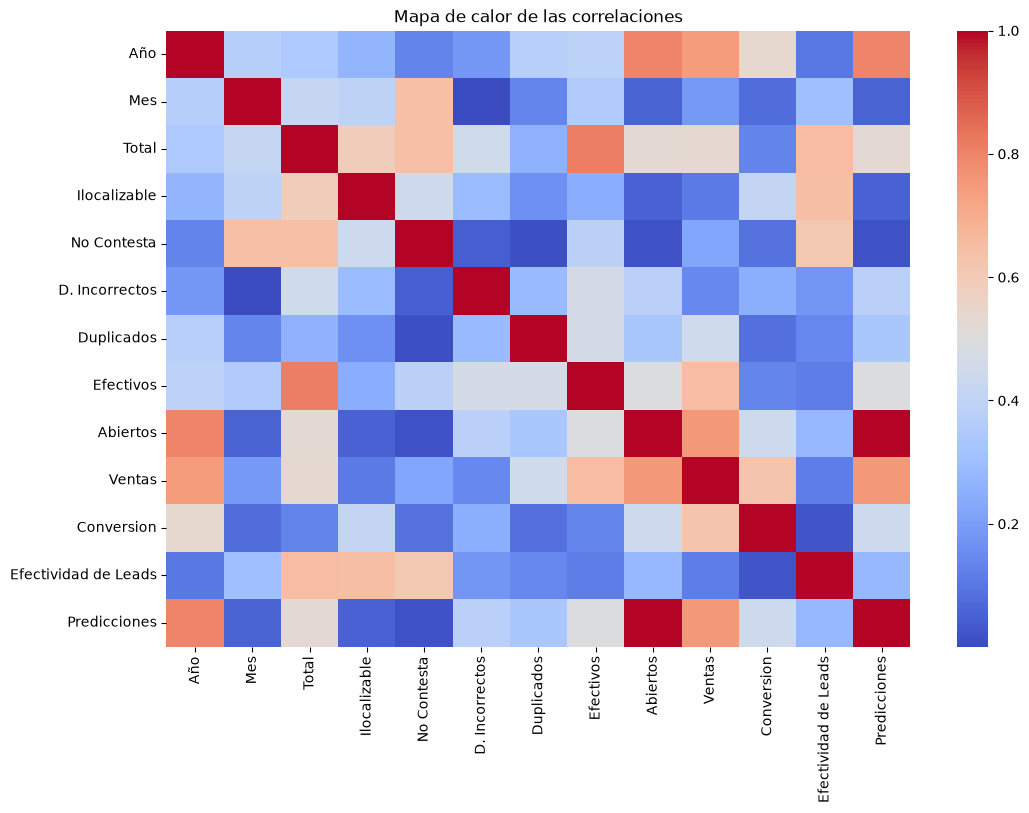

In [51]:
#Graficamos el mapa de calor
#de los coeficientes de correlación

plt.figure(figsize=(12, 8))

Heat_Map = sns.heatmap(
    Corr_Factors1,
    cmap="coolwarm"
)

plt.title("Mapa de calor de las correlaciones")
plt.show()

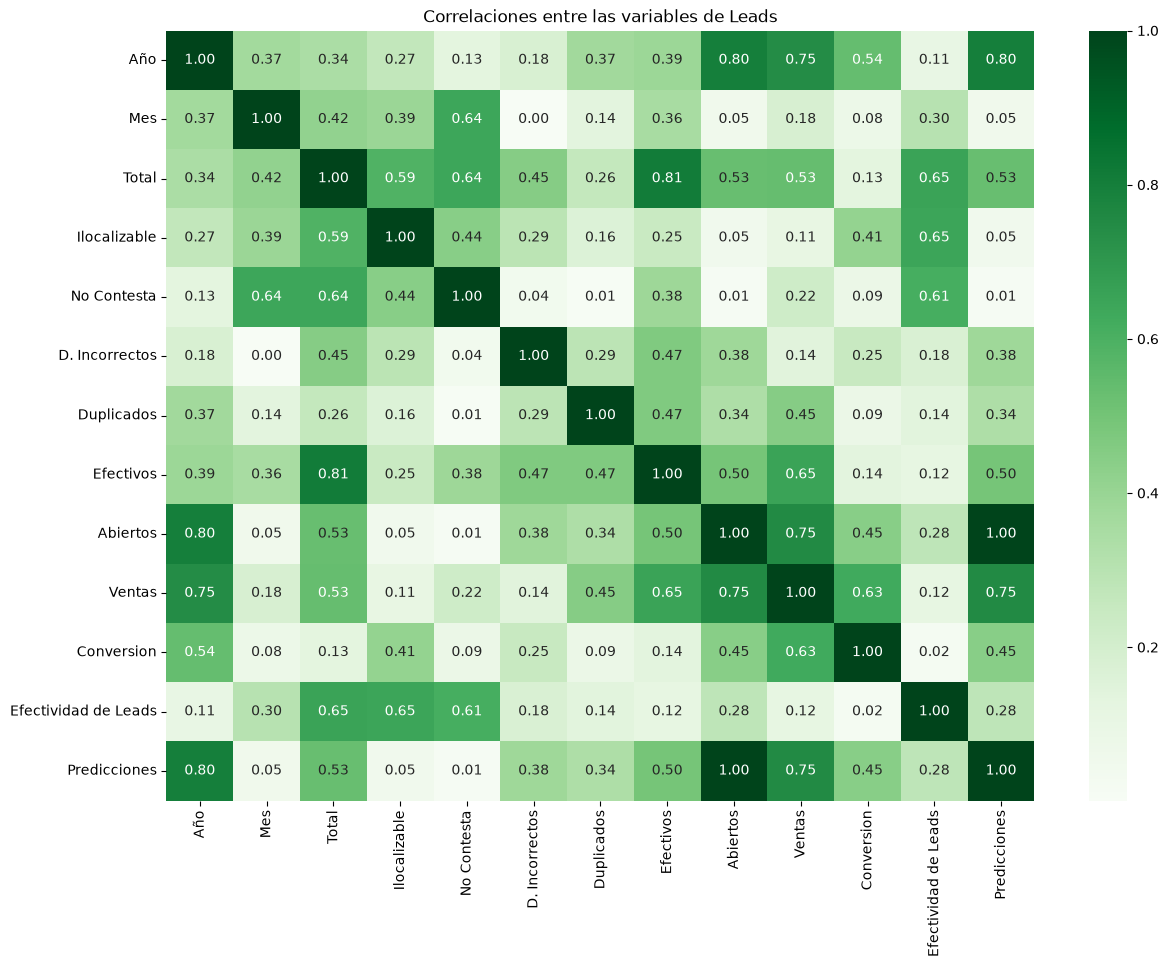

In [52]:
#Ajustamos el mapa de calor mostrando
#los valores de las correlaciones

plt.figure(figsize=(14, 10))

Heat_Map = sns.heatmap(
    Corr_Factors1,
    cmap="Greens",
    annot=True,
    fmt=".2f"
)

plt.title("Correlaciones entre las variables de Leads")
plt.show()

In [53]:
#Quitamos Predicciones únicamente del análisis de correlaciones

df_numerico = df.drop(
    columns=["Predicciones"],
    errors="ignore"
).select_dtypes(include=["number"])